# DTLZ4 Results

In [9]:
import multiprocessing
from functools import partial
from meamt_core import build_toolbox, gen_inicial_tables, run, generate_dtlz3_front_random
from deap import benchmarks

# 1. Parâmetros
K = 10
NPOP = 1000
NGEN = 300
NOBJ = 5 
IND_SIZE = NOBJ + K - 1 
NUM_TABLES = int((1 << NOBJ)) 
MAX_TABLE_SIZE = int(NPOP / NUM_TABLES)
REF_POINT_HV = [1.1]*NOBJ

# 2. Configurando o Toolbox de forma segura para o multiprocessing
# O 'partial' "congela" o argumento obj=NOBJ na função nativa do DEAP
func_dtlz4_segura = partial(benchmarks.dtlz4, obj=NOBJ, alpha=100)
toolbox = build_toolbox(func_dtlz4_segura, IND_SIZE, NPOP, NOBJ)

# =======================================================
# A TRAVA DE SEGURANÇA (OBRIGATÓRIA NO JUPYTER/WINDOWS)
# =======================================================
if __name__ == '__main__':
    # Cria o pool apenas se for o processo principal
    num_cores = multiprocessing.cpu_count() - 1 
    pool = multiprocessing.Pool(processes=num_cores)
    toolbox.register("map", pool.map) 

    # 3. Inicialização
    pop_inicial = toolbox.population()
    
    # Avaliação inicial
    fitnesses = toolbox.map(toolbox.evaluate, pop_inicial)
    for ind, fit in zip(pop_inicial, fitnesses):
        ind.fitness.values = fit

    tabelas = gen_inicial_tables(pop_inicial, NUM_TABLES, MAX_TABLE_SIZE, NOBJ)
    pareto_real = generate_dtlz3_front_random(NOBJ, 1000)
    reset = 40
    print(f"Iniciando evolução usando {num_cores} threads...")

    # 4. Executando o MEAMT
    logbook = run(tabelas, pareto_real, NUM_TABLES, MAX_TABLE_SIZE, NGEN, toolbox, 0.9, 1.0, REF_POINT_HV, NOBJ, reset)

    # Fechando os processos corretamente
    pool.close()
    pool.join()

    print("Evolução concluída!")

Iniciando evolução usando 15 threads...
Evolução concluída!


[1.0, 1.0, 0.0008487668872610766, 6.782848324373564e-05, 0.4999828036864699, 0.49985666655268896, 0.5000010455643232, 0.49993922397294277, 0.5000077117215844, 0.49991999796185566, 0.4996647351497095, 0.500006012797558, 0.5003183632449911, 0.49997107387562606]
[6.010618865910736e-05, 0.00022738985814080293, 2.540405149475955e-05, 0.00011131640802492003, 0.5000127270451442, 0.5000160622954433, 0.5000455277787234, 0.49998847675302993, 0.5000073229044593, 0.49995689858770404, 0.4999311017499861, 0.5000602056014647, 0.4999222666004932, 0.4999714316502514]
[1.0, 1.0, 1.0, 0.0008810670847738122, 0.49998280768979, 0.50000885035475, 0.49999767122982874, 0.4999886679434702, 0.5000082931862072, 0.4999805646376232, 0.49998278047965405, 0.49999978866308303, 0.5000181687658516, 0.499973982054502]
[0.9999999999999992, 0.00014878234343587704, 0.00018450002789618068, 0.00025071941689304217, 0.5192436787025854, 0.5001271568751366, 0.49397865817153597, 0.49999692561846865, 0.49921780260799664, 0.49998078

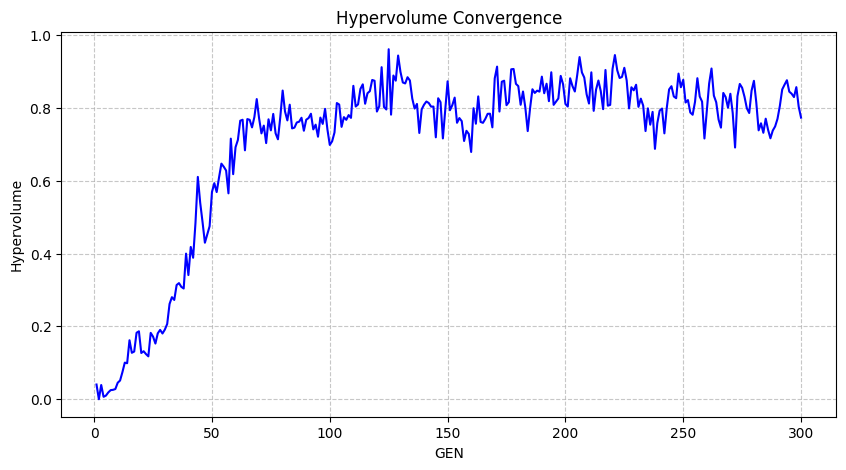

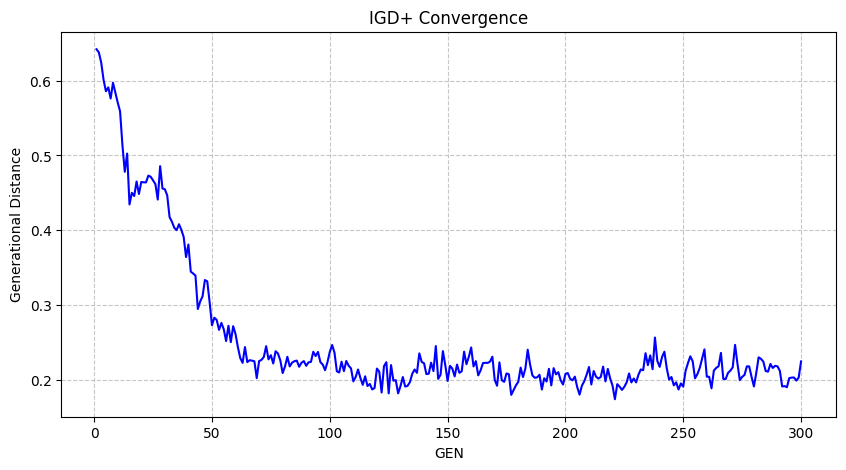

In [10]:
import matplotlib.pyplot as plt
# 3D Graphic of final pareto front
for ind in tabelas[0]:
   print(ind)
# Hypervolume Graphic
gen = logbook.select("gen")
fit_hv = logbook.select("hypervolume")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_hv, 'b-')
plt.title("Hypervolume Convergence")
plt.xlabel('GEN')
plt.ylabel('Hypervolume')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()
# IGD+ Graphic
gen = logbook.select("gen")
fit_igd = logbook.select("igd_plus")
plt.figure(figsize=(10, 5))
plt.plot(gen, fit_igd, 'b-')
plt.title("IGD+ Convergence")
plt.xlabel('GEN')
plt.ylabel('Generational Distance')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()